In [1]:
import numpy as np
import torch 
import gymnasium as gym
import matplotlib.pyplot as plt

from copy import deepcopy
from tqdm import tqdm
from four_room.env import FourRoomsEnv
from four_room.wrappers import gym_wrapper
from four_room.constants import state_to_q
from rnd_exploration.dataset import State
from four_room.constants import train_config, val_config, test_config, size
from uvu.uvu import UVU
from dqn.model import DQN
from utils.episode import LastEpisode
from utils.record_scores import record_uvu_scores, record_dqn_scores
from four_room.utils import obs_to_state

gym.register('MiniGrid-FourRooms-v1', FourRoomsEnv)


%load_ext autoreload
%autoreload 2

In [2]:

env = gym_wrapper(gym.make(
            'MiniGrid-FourRooms-v1', 
            agent_pos= train_config['agent positions'],
            goal_pos = train_config['goal positions'],
            doors_pos = train_config['topologies'],
            agent_dir = train_config['agent directions'],
            size=size, 
            render_mode='rgb_array',
            disable_env_checker=True
        ),
        original_obs=True
    )
    
val_env = gym_wrapper(gym.make(
        'MiniGrid-FourRooms-v1', 
        agent_pos= train_config['agent positions'],
        goal_pos = train_config['goal positions'],
        doors_pos = train_config['topologies'],
        agent_dir = train_config['agent directions'],
        size=size
    ),
    original_obs=True
)

In [3]:
obs, _ = env.reset()

In [34]:
agent = UVU(
    env=env,
    val_env=val_env,
    capacity=1000,
    tau=0.01,
    lr=3e-4,
    device='cuda',
    use_cnn=True,
    cnn_features=512,
    hidden_layers=[512, 512, 512],
    hidden_layers_g=[512, 512, 512],
    residual=True,
    init='kaiming',
    num_heads=512,
    use_state=False,
    stack_linear=False
)

action = torch.randint(0, 3, (1, 1)).to('cuda')
# agent.epistemic(torch.from_numpy(obs).unsqueeze(dim=0).to('cuda').float(), action)
agent.epistemic(agent.get_obs(obs), action)


tensor([[2.5853]], device='cuda:0')

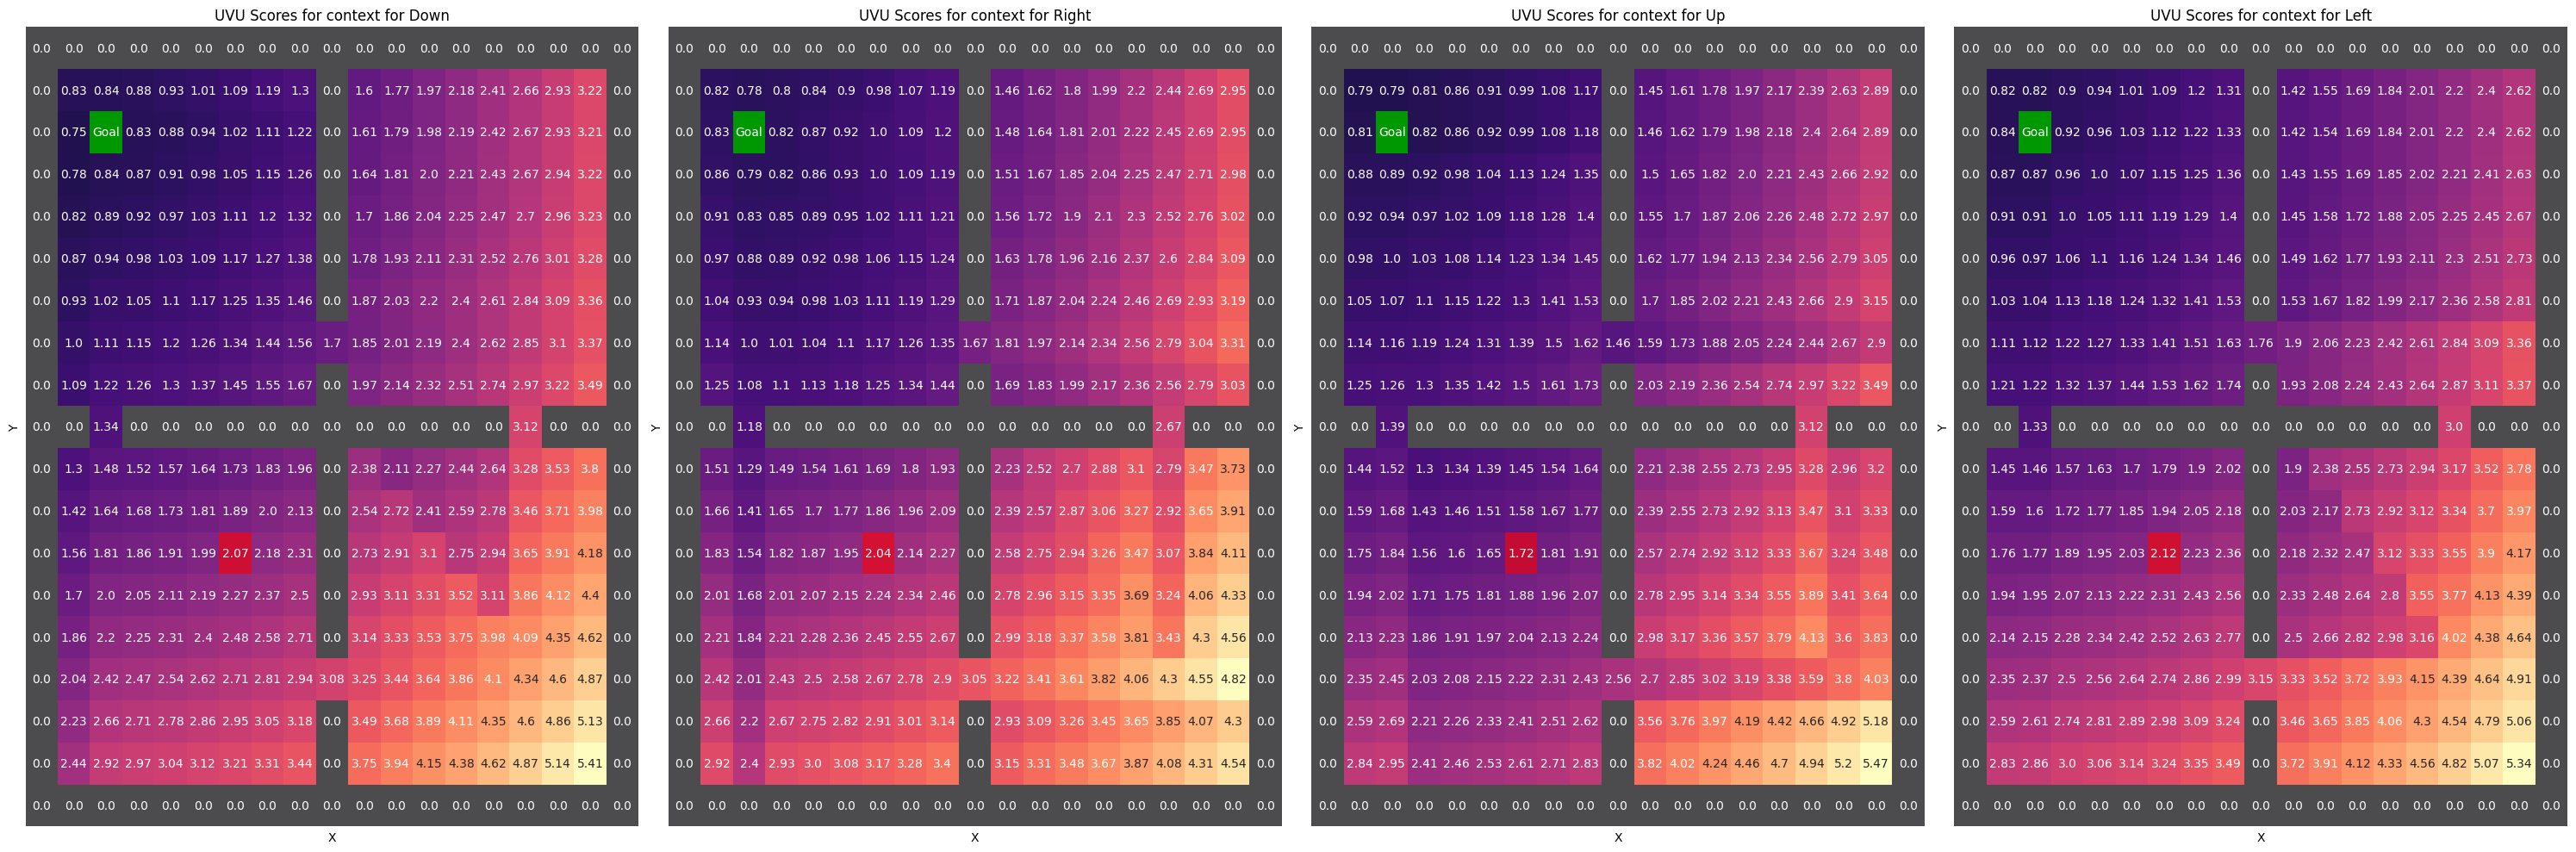

In [34]:
from plot_interactive import find_states, plot_env_heatmap

agent = UVU(
    env=env,
    val_env=val_env,
    capacity=1000,
    tau=0.005,
    lr=1e-3,
    device='cuda',
    use_cnn=False,
    cnn_features=512,
    hidden_layers=[512, 512, 512],
    hidden_layers_g=[512, 512, 512],
    residual=False,
    init='kaiming',
    num_heads=512,
    use_state=True,
    stack_linear=False
)

# agent = DQN(
#     env=env,
#     val_env=val_env,
#     capacity=1000,
#     tau=0.001,
#     lr=3e-4,
#     device='cuda',
#     use_cnn=True,
#     cnn_features=1024,
#     hidden_layers=[1024, 2048, 1024],
#     residual=True
# )

fig, axes = plt.subplots(1, 4, figsize=(30, 10))
context = 0
_, _, uvu_scores = record_uvu_scores(agent, context, 0, render=True)
uvu_scores = uvu_scores / 100 
env.get_wrapper_attr('set_context')(context)
obs, _ = env.reset()
context_info = env.get_wrapper_attr('context_info')(context)
context_info = (*context_info, env.get_wrapper_attr('valid_pos'))
agent_pos = env.get_wrapper_attr('agent_pos')

plot_env_heatmap(
    uvu_scores[0].squeeze(),
    context_info,
    'UVU Scores',
    f'UVU Scores for context for Down',
    axes[0],
    agent_pos=agent_pos,
    intize=False
)

plot_env_heatmap(
    uvu_scores[1].squeeze(),
    context_info,
    'UVU Scores',
    f'UVU Scores for context for Right',
    axes[1],
    agent_pos=agent_pos,
    intize=False,
)

plot_env_heatmap(
    uvu_scores[2].squeeze(),
    context_info,
    'UVU Scores',
    f'UVU Scores for context for Up',
    axes[2],
    agent_pos=agent_pos,
    intize=False
)

plot_env_heatmap(
    uvu_scores[3].squeeze(),
    context_info,
    'UVU Scores',
    f'UVU Scores for context for Left',
    axes[3],
    agent_pos=agent_pos,
    intize=False
)


plt.tight_layout()


In [31]:
done = False
context = 0
env.get_wrapper_attr('set_context')(context)
obs, _ = env.reset()
for step in tqdm(range(1, 50000)):
    q = state_to_q[State(state=obs)]
    action = q.argmax() if isinstance(q, np.ndarray) else np.array(q).argmax()
    
    obs_prime, reward, terminated, truncated, _ = env.step(action)
    done = terminated or truncated
    q_next = state_to_q[State(state=obs_prime)] if not done else np.array([0, 0, 0])
    next_action = q_next.argmax()
    
    state = obs_to_state(obs)
    if done:
        env.get_wrapper_attr('set_context')(context)
        prime_state = np.array((env.agent_pos[0], env.agent_pos[1], env.agent_dir, env.goal_pos[0], 
                                env.goal_pos[0], *state[5:]))
        obs, _ = env.reset()
        done = False
    else: 
        prime_state = np.array(obs_to_state(obs_prime))
        obs = obs_prime
        
    agent.buffer.update(np.array(obs_to_state(obs)), action, reward, prime_state, next_action, int(done), q_value=q)
    
    if agent.buffer.size > 128:
        agent.update_step(128)
        agent.soft_update()
    

  0%|          | 0/49999 [00:00<?, ?it/s]c:\Users\garga\Documents\Uni\RND DQN\four_room\venv\Lib\site-packages\gymnasium\core.py:311: UserWarning: WARN: env.agent_pos to get variables from other wrappers is deprecated and will be removed in v1.0, to get this variable you can do `env.unwrapped.agent_pos` for environment variables or `env.get_wrapper_attr('agent_pos')` that will search the reminding wrappers.
  logger.warn(
c:\Users\garga\Documents\Uni\RND DQN\four_room\venv\Lib\site-packages\gymnasium\core.py:311: UserWarning: WARN: env.agent_dir to get variables from other wrappers is deprecated and will be removed in v1.0, to get this variable you can do `env.unwrapped.agent_dir` for environment variables or `env.get_wrapper_attr('agent_dir')` that will search the reminding wrappers.
  logger.warn(
c:\Users\garga\Documents\Uni\RND DQN\four_room\venv\Lib\site-packages\gymnasium\core.py:311: UserWarning: WARN: env.goal_pos to get variables from other wrappers is deprecated and will be r

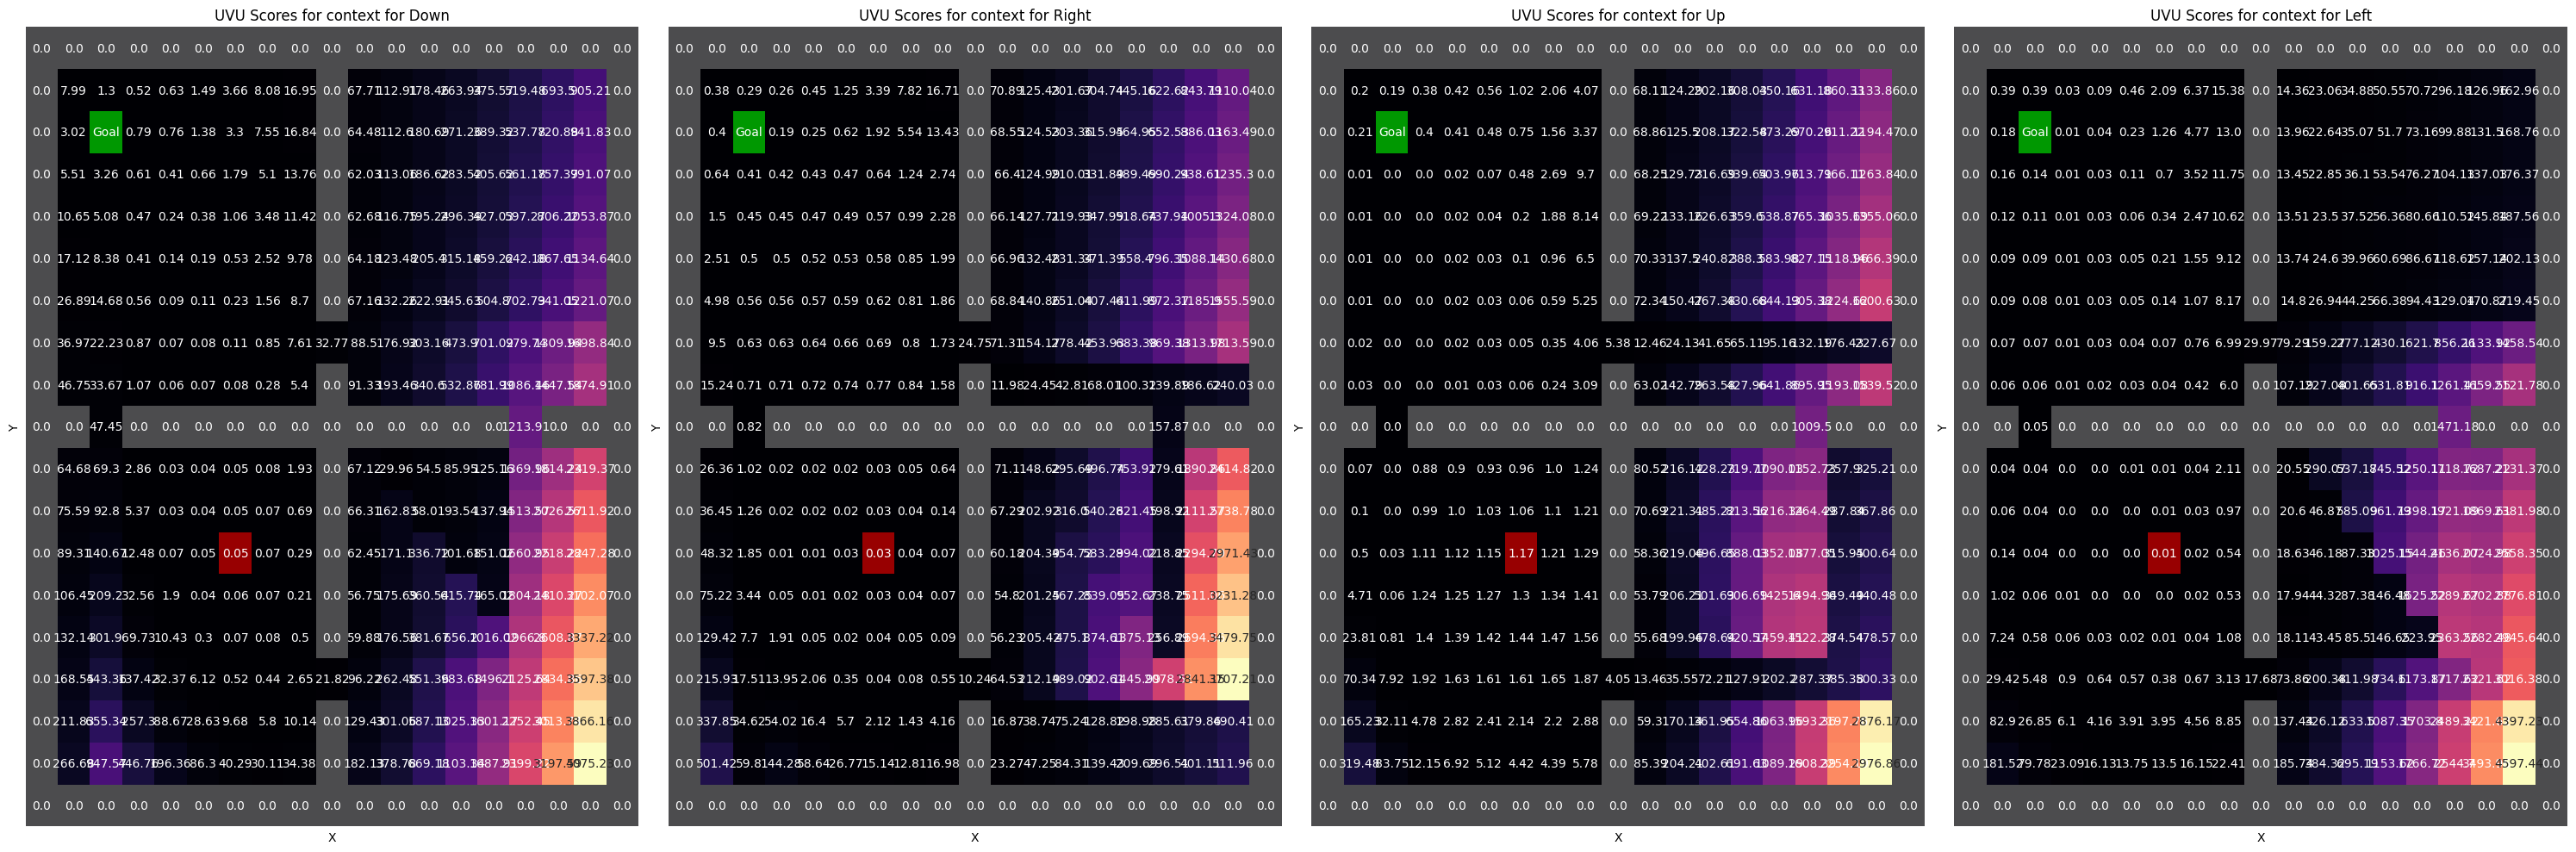

In [33]:
from plot_interactive import find_states, plot_env_heatmap

fig, axes = plt.subplots(1, 4, figsize=(30, 10))
context = 0
_, _, uvu_scores = record_uvu_scores(agent, context, 0)
uvu_scores = uvu_scores / 100 
env.get_wrapper_attr('set_context')(context)
obs, _ = env.reset()
context_info = env.get_wrapper_attr('context_info')(context)
context_info = (*context_info, env.get_wrapper_attr('valid_pos'))
agent_pos = env.get_wrapper_attr('agent_pos')

plot_env_heatmap(
    uvu_scores[0].squeeze(),
    context_info,
    'UVU Scores',
    f'UVU Scores for context for Down',
    axes[0],
    agent_pos=agent_pos,
    intize=False
)

plot_env_heatmap(
    uvu_scores[1].squeeze(),
    context_info,
    'UVU Scores',
    f'UVU Scores for context for Right',
    axes[1],
    agent_pos=agent_pos,
    intize=False
)

plot_env_heatmap(
    uvu_scores[2].squeeze(),
    context_info,
    'UVU Scores',
    f'UVU Scores for context for Up',
    axes[2],
    agent_pos=agent_pos,
    intize=False
)

plot_env_heatmap(
    uvu_scores[3].squeeze(),
    context_info,
    'UVU Scores',
    f'UVU Scores for context for Left',
    axes[3],
    agent_pos=agent_pos,
    intize=False
)


plt.tight_layout()


In [52]:
# buffer = agent.buffer
agent = UVU(
    env=env,
    val_env=val_env,
    capacity=1000,
    tau=0.01,
    lr=3e-4,
    device='cuda',
    use_cnn=False,
    cnn_features=512,
    hidden_layers=[512, 512, 512],
    hidden_layers_g=[512, 512, 512],
    residual=True,
    init='kaiming',
    num_heads=512,
    use_state=True,
    stack_linear=False
)
agent.buffer = buffer

In [10]:
a = torch.randn((16, 10, 1))
b = torch.randn_like(a)
mask = torch.randint(0, 2, (16, 10))

In [11]:
a, b, mask

(tensor([[[-0.4109],
          [ 0.2161],
          [-0.8533],
          [ 0.2332],
          [-0.2680],
          [-0.2504],
          [ 0.9485],
          [ 0.3954],
          [ 0.3707],
          [-0.5288]],
 
         [[-1.2828],
          [ 0.5552],
          [-2.2982],
          [-0.7814],
          [-0.4655],
          [-0.9256],
          [-1.4000],
          [-0.0806],
          [ 0.8400],
          [-0.7138]],
 
         [[ 0.8390],
          [-0.2038],
          [ 0.0893],
          [ 0.7638],
          [ 2.1587],
          [ 0.3887],
          [ 1.1120],
          [-0.4670],
          [ 2.4811],
          [-0.1862]],
 
         [[-0.4679],
          [ 0.0462],
          [ 0.0896],
          [ 0.7526],
          [ 1.8053],
          [ 0.2550],
          [-0.7795],
          [ 0.7687],
          [-0.6931],
          [-1.6032]],
 
         [[-0.6277],
          [ 0.6090],
          [ 0.2737],
          [-0.6931],
          [-0.6320],
          [ 1.4789],
          [-1.3440],
 

False

In [53]:
agent.update_step(128)

torch.Size([128, 512, 1]) torch.Size([128, 512]) torch.Size([128, 512, 1]) torch.Size([128, 512])
